##### CM4708 - Data Science Trends and Applications

##### Sample Code

For the following sample code, I will demonstrate that video can be imported in mpg format and converted to mp4 format.  Following that I intend to pre-process the video footage by applying CLAHE (Contrast Limited Adaptive Histogram Equalization) to the video frames.  This will be done using the OpenCV library.  The pre-processed video will then be saved as a new file.

1. First I will import the raw footage and convert it to mp4 format.  Within the raw_footage folder there are 3 files in mpg format that need to be converted.

In [1]:
# Import the required packages
import os
import numpy as np
import cv2
import subprocess
import random
import matplotlib.pyplot as plt

In [2]:
# Specify the folders for the raw and converted footage
raw_folder = r"C:\Users\Stuart Houston\Documents\CM4708_Coursework\raw_footage"
converted_folder = r"C:\Users\Stuart Houston\Documents\CM4708_Coursework\converted_footage"

# Covert mpg files to mp4 files
def convert_video(input_file, output_file):
    command = f"ffmpeg -i \"{input_file}\" \"{output_file}\""
    subprocess.run(command, shell=True)

# Iterate through all video files in the raw folder
for filename in os.listdir(raw_folder):
    if filename.endswith(".mpg"):
        input_video_path = os.path.join(raw_folder, filename)
        output_video_path = os.path.join(converted_folder, filename.replace(".mpg", ".mp4"))

        # Convert each video file
        convert_video(input_video_path, output_video_path)

2. Now that the video files are converted from mpg to mp4 lets sample some random frames to ensure that the conversion has worked

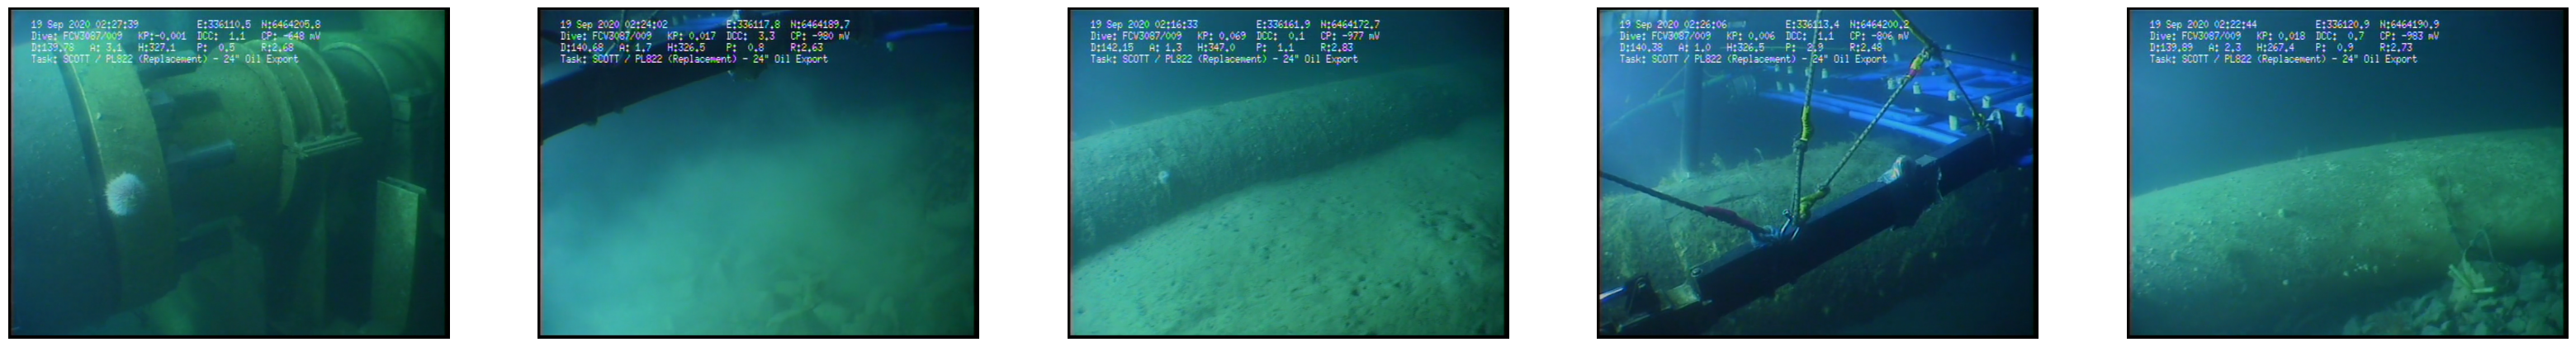

In [3]:
# Open the converted video file
cap = cv2.VideoCapture(output_video_path)

# Get the total number of frames in the video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Specify the number of frames to grab
num_frames_to_grab = 5

# Ensure uniform sampling across the entire video
frames_to_grab = random.sample(range(total_frames), num_frames_to_grab)

# Create a subplot with 1 row and num_frames_to_grab columns
fig, axes = plt.subplots(1, num_frames_to_grab, figsize=(8* num_frames_to_grab, 8))

# Grab and display the frames using matplotlib
for i, frame_num in enumerate(frames_to_grab):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
    ret, frame = cap.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    axes[i].imshow(frame_rgb)
    axes[i].axis('off')  # Turn off axis labels

plt.show()

cap.release()

3. Now that I have confirmed the video files have been converted to mp4, the next step will be to apply CLAHE to preprocess my video

In [4]:
# Open the converted video file
cap = cv2.VideoCapture(output_video_path)

# Create a VideoWriter object to save the CLAHE-enhanced video
output_clahe_path = output_video_path.replace(".mp4", "_clahe.mp4")
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_clahe_path, fourcc, cap.get(cv2.CAP_PROP_FPS), (int(cap.get(3)), int(cap.get(4))))

# Define the CLAHE filter
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE to each frame and write to the new video file
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert the frame to LAB color model 
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2Lab)

    # Split the LAB image into L, A and B channels
    l, a, b = cv2.split(lab)

    # Apply the CLAHE to the L channel
    cl = clahe.apply(l)

    # Merge the CLAHE enhanced L channel with the A and B channel
    limg = cv2.merge((cl,a,b))

    # Convert image back to RGB color model
    final = cv2.cvtColor(limg, cv2.COLOR_Lab2BGR)

    # Write the enhanced frame to the new video file
    out.write(final)

# Release the VideoCapture and VideoWriter objects
cap.release()
out.release()

# Display a message once conversion has been completed
print(f"CLAHE applied and saved to {output_clahe_path}")

CLAHE applied and saved to C:\Users\Stuart Houston\Documents\CM4708_Coursework\converted_footage\VIDEO_202009190115540_Stbd_clahe.mp4


4. Randomly sample frames from the preprocessed video and display some before and after frames to determine whether CLAHE has been successfully applied.

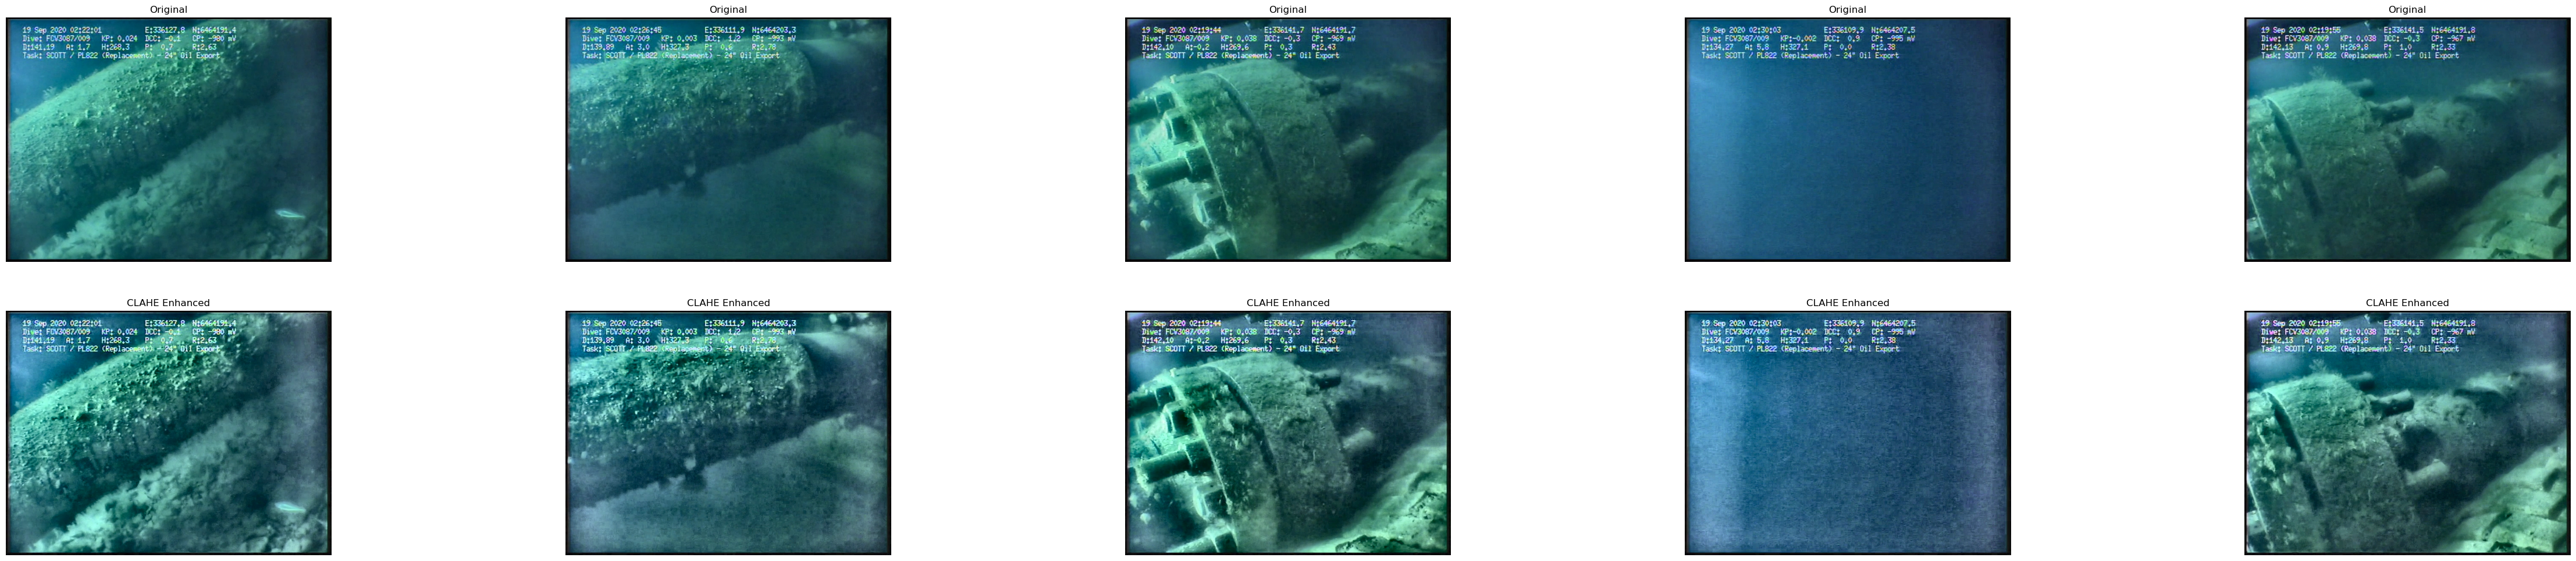

In [6]:
# Open the CLAHE-enhanced video file
cap_clahe = cv2.VideoCapture(output_clahe_path)

# Get the total number of frames in the CLAHE-enhanced video
total_frames_clahe = int(cap_clahe.get(cv2.CAP_PROP_FRAME_COUNT))

# Specify the number of frames to grab after CLAHE
num_frames_to_grab_clahe = 5

# Ensure uniform sampling across the entire CLAHE-enhanced video
frames_to_grab_clahe = random.sample(range(total_frames_clahe), num_frames_to_grab_clahe)

# Create a subplot with 2 rows and num_frames_to_grab_clahe columns
fig_clahe, axes_clahe = plt.subplots(2, num_frames_to_grab_clahe, figsize=(12 * num_frames_to_grab_clahe, 12))

# Define the CLAHE filter
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Grab and display the frames using matplotlib before and after CLAHE
for i, frame_num_clahe in enumerate(frames_to_grab_clahe):
    # Display the original frame
    cap_clahe.set(cv2.CAP_PROP_POS_FRAMES, frame_num_clahe)
    ret, frame = cap_clahe.read()
    if not ret:
        break
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    axes_clahe[0, i].imshow(frame_rgb)
    axes_clahe[0, i].axis('off')  # Turn off axis labels
    axes_clahe[0, i].set_title('Original')

    # Convert the frame to LAB color model 
    lab = cv2.cvtColor(frame, cv2.COLOR_BGR2Lab)

    # Split the LAB image into L, A and B channels
    l, a, b = cv2.split(lab)

    # Apply the CLAHE to the L channel
    cl = clahe.apply(l)

    # Merge the CLAHE enhanced L channel with the A and B channel
    limg = cv2.merge((cl,a,b))

    # Convert image back to RGB color model
    final = cv2.cvtColor(limg, cv2.COLOR_Lab2RGB)

    # Display the enhanced frame
    axes_clahe[1, i].imshow(final)
    axes_clahe[1, i].axis('off')  # Turn off axis labels
    axes_clahe[1, i].set_title('CLAHE Enhanced')

plt.show()

# Release the CLAHE-enhanced VideoCapture object
cap_clahe.release()